# Geographically Weighted Regression (GWR)
## Do Drivers of Electrification Vary Across Space?

**Author:** Bouchra Daddaoui

OLS and spatial lag models assume that the relationship between predictors and NTL is *constant* everywhere.
That assumption is almost certainly wrong — infrastructure density might matter more in dense urban fringes,
while distance to city might dominate in rural Morocco but not in coastal Brazil.

Geographically Weighted Regression (GWR) fits a *local* regression at each tile using a spatial kernel,
so coefficients vary continuously across space. We use **Multiscale GWR (MGWR)**, which lets each
predictor have its own bandwidth — the scale at which its effect operates.

**Key outputs:**
1. GWR vs OLS model comparison (AIC, R²)
2. MGWR bandwidth table — what spatial scale does each variable operate at?
3. Local coefficient maps — where does each predictor matter?
4. Local R² map — where does the model fit well vs poorly?


In [1]:
import sys
sys.path.insert(0, '../scripts')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from gwr_analysis import (
    prep_coords, run_gwr, run_mgwr,
    gwr_coefficient_maps, gwr_r2_map,
    gwr_vs_ols_summary, bandwidth_summary
)

FIGURES = Path('../figures')
np.random.seed(42)
print('Ready.')

Ready.


## 1. Data — Synthetic VIIRS panel (same as previous notebooks)

In [2]:
from shapely.geometry import box

def make_gdf(country, n, bbox, ntl_mean, ntl_std, seed):
    rng = np.random.default_rng(seed)
    minx, miny, maxx, maxy = bbox
    cols = int(np.sqrt(n)); rows = n // cols
    xs = np.linspace(minx, maxx, cols + 1)
    ys = np.linspace(miny, maxy, rows + 1)
    geoms = [box(xs[j], ys[i], xs[j+1], ys[i+1])
             for i in range(rows) for j in range(cols)]
    n_act = len(geoms)
    centroids = np.array([[g.centroid.x, g.centroid.y] for g in geoms])
    dists = np.linalg.norm(centroids[:, None] - centroids[None, :], axis=-1)
    cov = ntl_std**2 * np.exp(-dists / (0.3 * (maxx - minx)))
    ntl = rng.multivariate_normal(np.full(n_act, ntl_mean), cov)
    ntl = np.clip(ntl, 0, None)
    return gpd.GeoDataFrame({
        'country': country,
        'ntl_mean': ntl,
        'pop_density':   rng.lognormal(np.log(100), 1.2, n_act),
        'infra_density': 0.4 * ntl / (ntl.max() + 1e-9) + 0.6 * rng.uniform(0, 1, n_act),
        'dist_city_km':  rng.exponential(50, n_act),
        'hand_mean_m':   rng.lognormal(np.log(5), 0.8, n_act),
        'gdp_proxy':     0.6 * ntl + rng.normal(0, 1, n_act),
    }, geometry=geoms, crs='EPSG:4326')

configs = [
    dict(country='Brazil',  n=100, bbox=(-48,-23,-43,-18), ntl_mean=12.5, ntl_std=8.0,  seed=1),
    dict(country='China',   n=100, bbox=(116, 29, 122, 33), ntl_mean=28.3, ntl_std=14.0, seed=2),
    dict(country='Morocco', n=100, bbox=(-17.1, 20.8, -1.0, 35.9), ntl_mean=8.1,  ntl_std=5.5,  seed=3),
]

gdfs = {c['country']: make_gdf(**c) for c in configs}
FEATURES = ['pop_density', 'infra_density', 'dist_city_km', 'hand_mean_m', 'gdp_proxy']

for c, g in gdfs.items():
    print(f"{c}: {len(g)} tiles")

Brazil: 100 tiles
China: 100 tiles
Morocco: 100 tiles


## 2. GWR vs OLS — Is Spatial Non-Stationarity Worth Modelling?

If ΔAIC(OLS − GWR) > 2, GWR is preferred over OLS.

In [3]:
gwr_results_all = {}

for country, gdf in gdfs.items():
    print(f"\n{'='*45}")
    print(f"Running GWR for {country}...")
    results, bw, _ = run_gwr(gdf, 'ntl_mean', FEATURES)
    gwr_results_all[country] = results
    comp = gwr_vs_ols_summary(gdf, 'ntl_mean', FEATURES, results)
    print(f"  Optimal bandwidth: {bw:.1f} tiles")
    print(f"  Mean local R²: {results.localR2.mean():.4f}")


Running GWR for Brazil...


Model Comparison: OLS vs GWR
  OLS  AIC = 404.47 | R² = 0.8986


  GWR  AIC = 406.26 | Mean local R² = 0.9078
  ΔAIC (OLS - GWR) = -1.79  → OLS comparable
  Optimal bandwidth: 99.0 tiles
  Mean local R²: 0.9078

Running GWR for China...


Model Comparison: OLS vs GWR
  OLS  AIC = 378.24 | R² = 0.9842
  GWR  AIC = 383.11 | Mean local R² = 0.9834
  ΔAIC (OLS - GWR) = -4.86  → OLS comparable
  Optimal bandwidth: 62.0 tiles
  Mean local R²: 0.9834

Running GWR for Morocco...


Model Comparison: OLS vs GWR
  OLS  AIC = 358.31 | R² = 0.9143
  GWR  AIC = 353.23 | Mean local R² = 0.8796
  ΔAIC (OLS - GWR) = 5.07  → GWR preferred
  Optimal bandwidth: 72.0 tiles
  Mean local R²: 0.8796


## 3. MGWR — Each Predictor at Its Own Spatial Scale

In [4]:
# Run MGWR on Morocco (most interesting for electrification policy — Western Sahara gradient)
print("Running MGWR for Morocco (includes Western Sahara)...")
mgwr_results_morocco, bws_morocco, _ = run_mgwr(gdfs['Morocco'], 'ntl_mean', FEATURES)
bandwidth_summary(FEATURES, bws_morocco)

Running MGWR for Morocco (includes Western Sahara)...


Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

Inference:   0%|          | 0/1 [00:00<?, ?it/s]


MGWR Bandwidth Summary (larger = more global effect)
---------------------------------------------
  Intercept           :   81.0  ████████████████
  pop_density         :   88.0  █████████████████
  infra_density       :   99.0  ███████████████████
  dist_city_km        :   98.0  ███████████████████
  hand_mean_m         :   99.0  ███████████████████
  gdp_proxy           :   79.0  ███████████████


## 4. Local Coefficient Maps — Where Does Each Feature Matter?

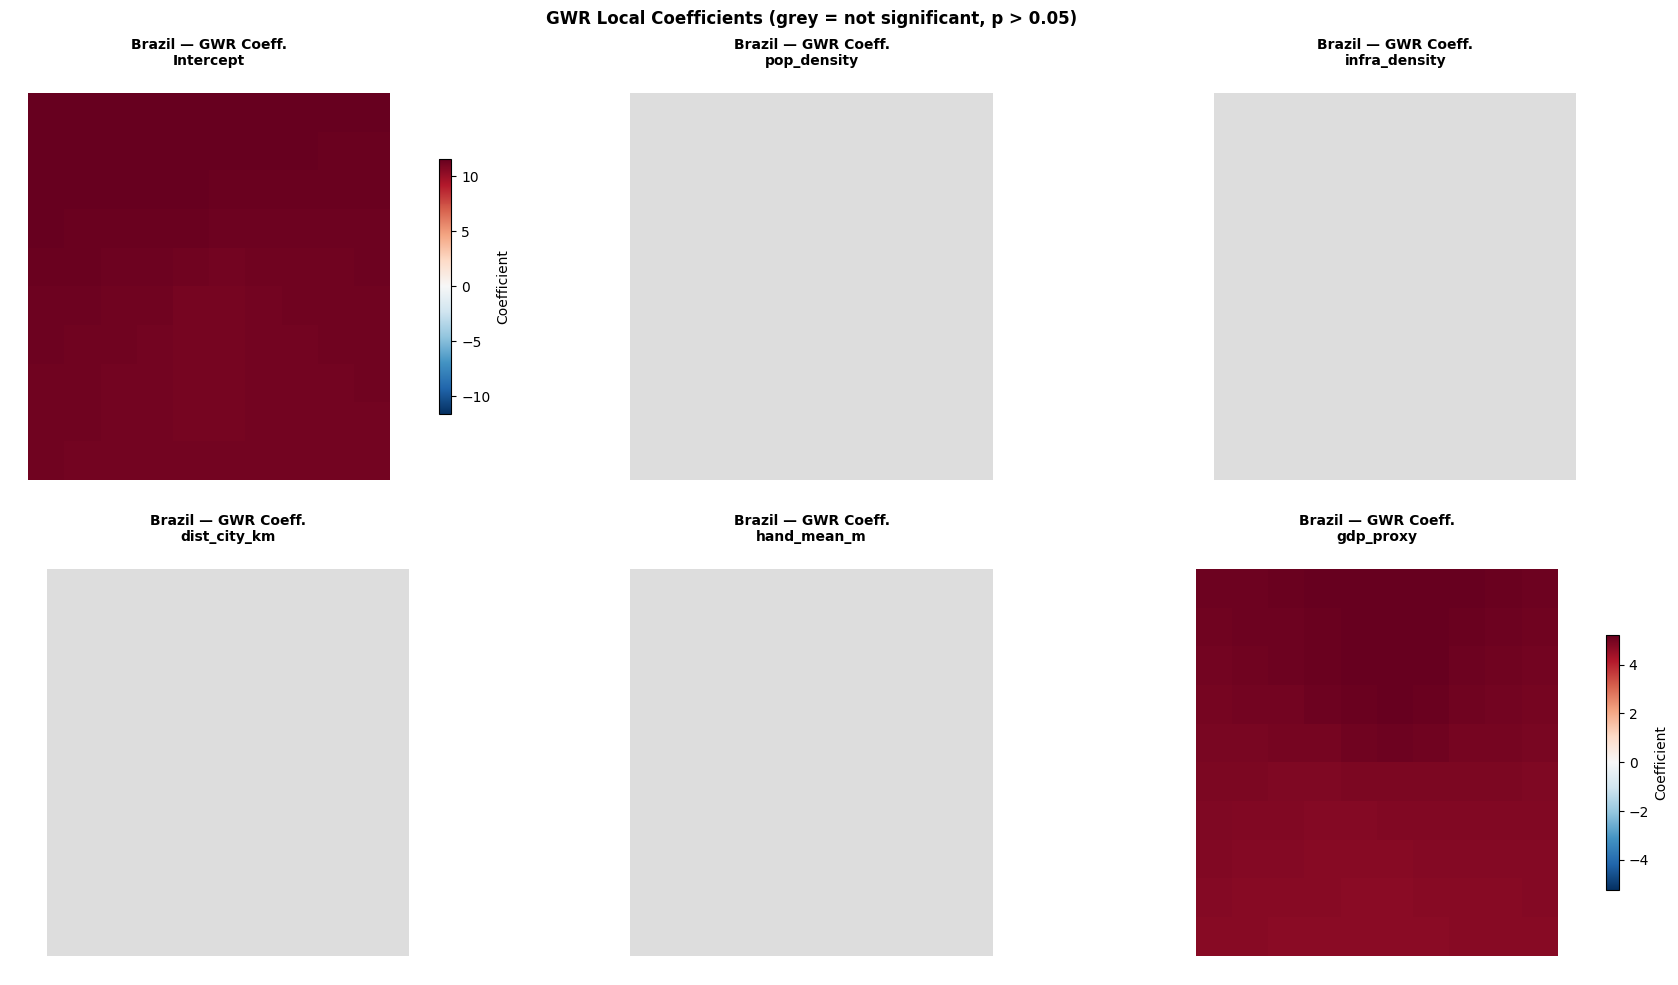

Saved → figures/gwr_coefficients_brazil.png


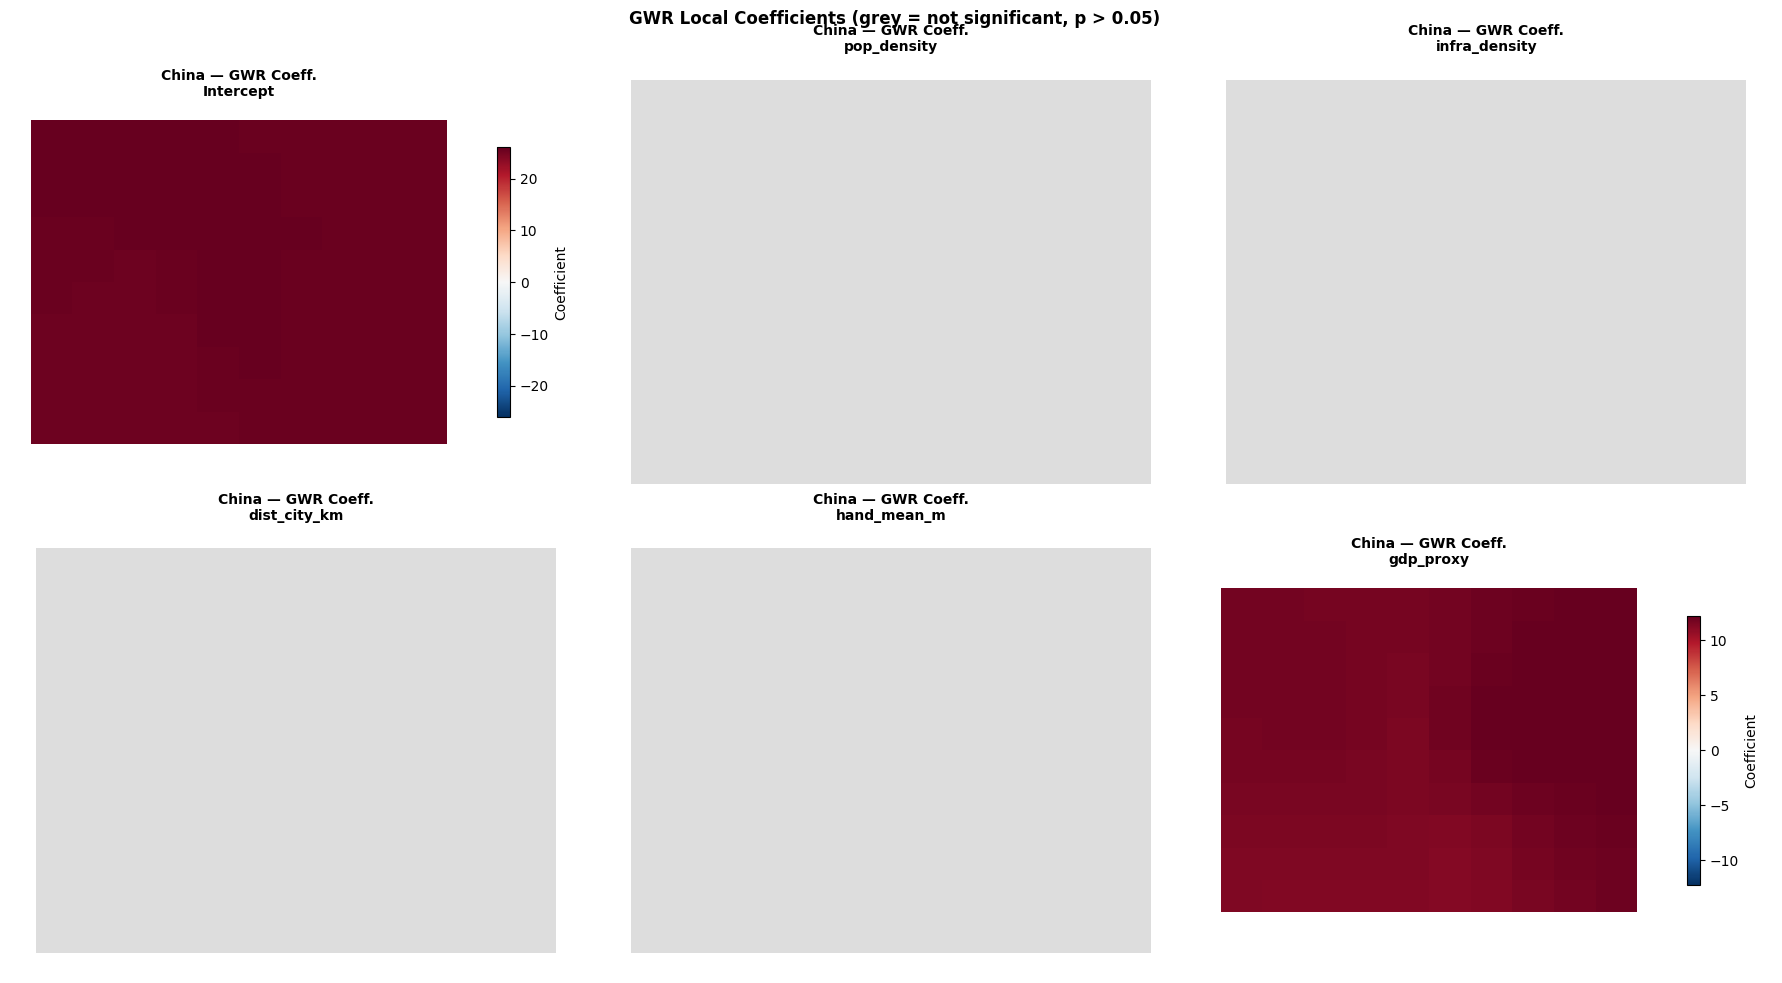

Saved → figures/gwr_coefficients_china.png


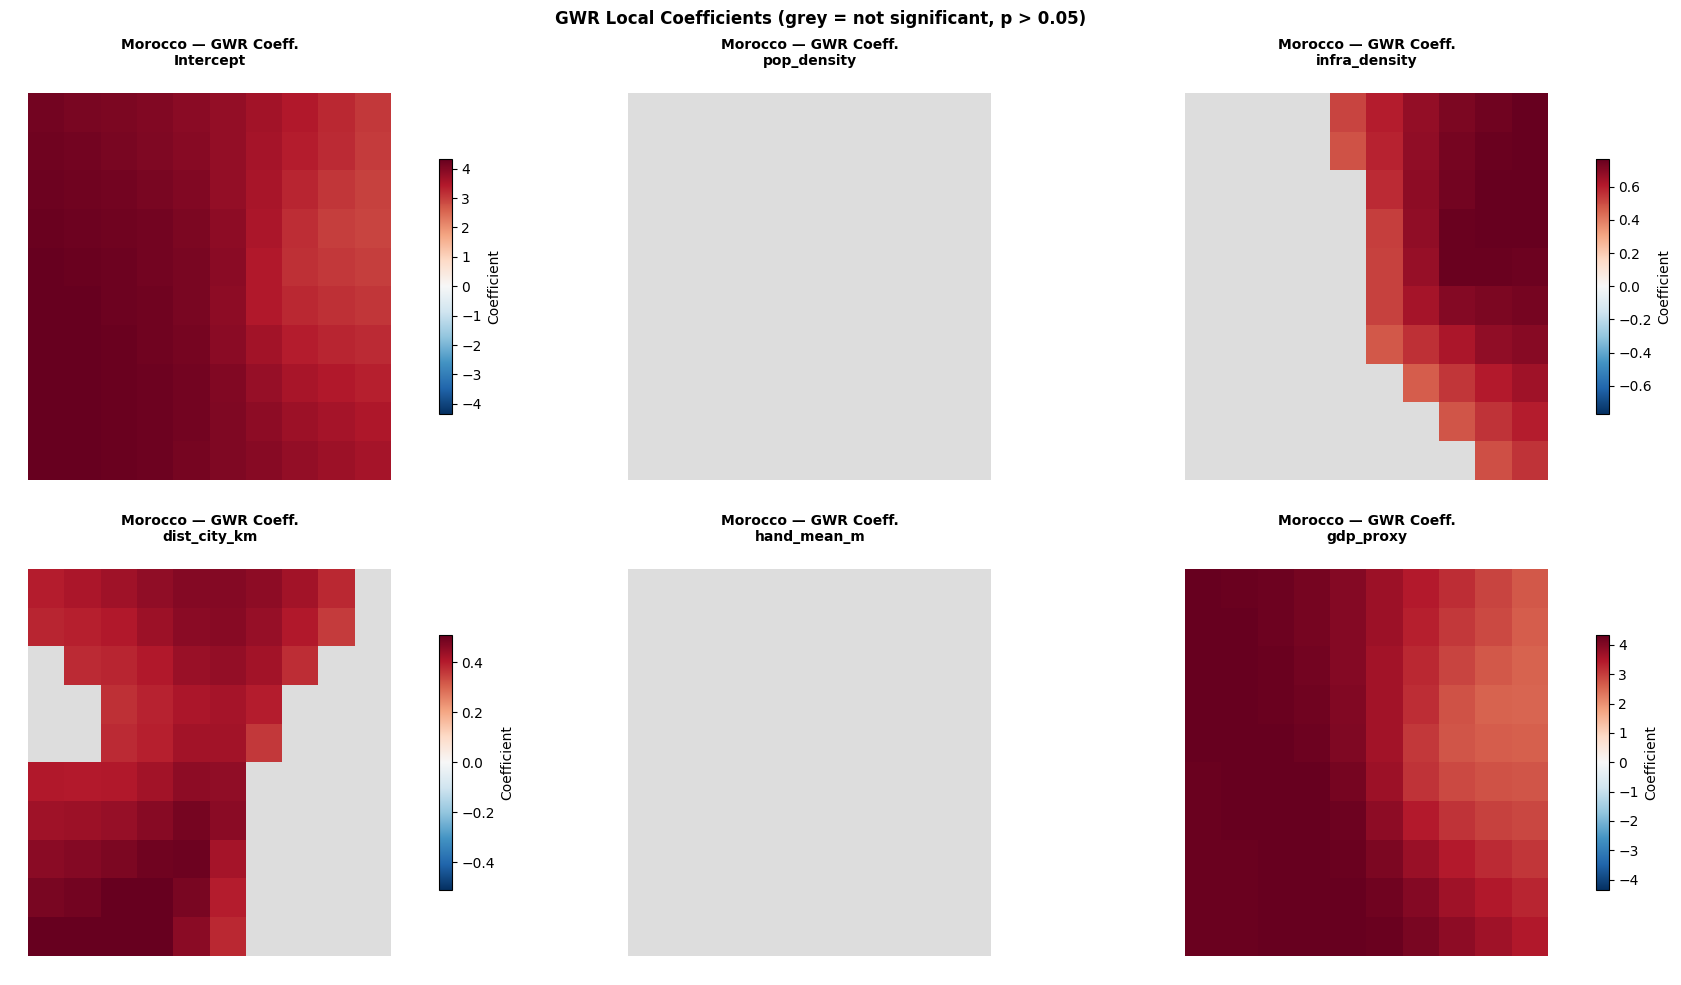

Saved → figures/gwr_coefficients_morocco.png


In [5]:
for country, gdf in gdfs.items():
    results = gwr_results_all[country]
    fig = gwr_coefficient_maps(
        gdf, results, FEATURES,
        title_prefix=f'{country} — GWR Coeff.',
        save_path=str(FIGURES / f'gwr_coefficients_{country.lower()}.png')
    )
    plt.show()
    print(f'Saved → figures/gwr_coefficients_{country.lower()}.png')

## 5. Local R² Maps — Where Does the Model Fit Well?

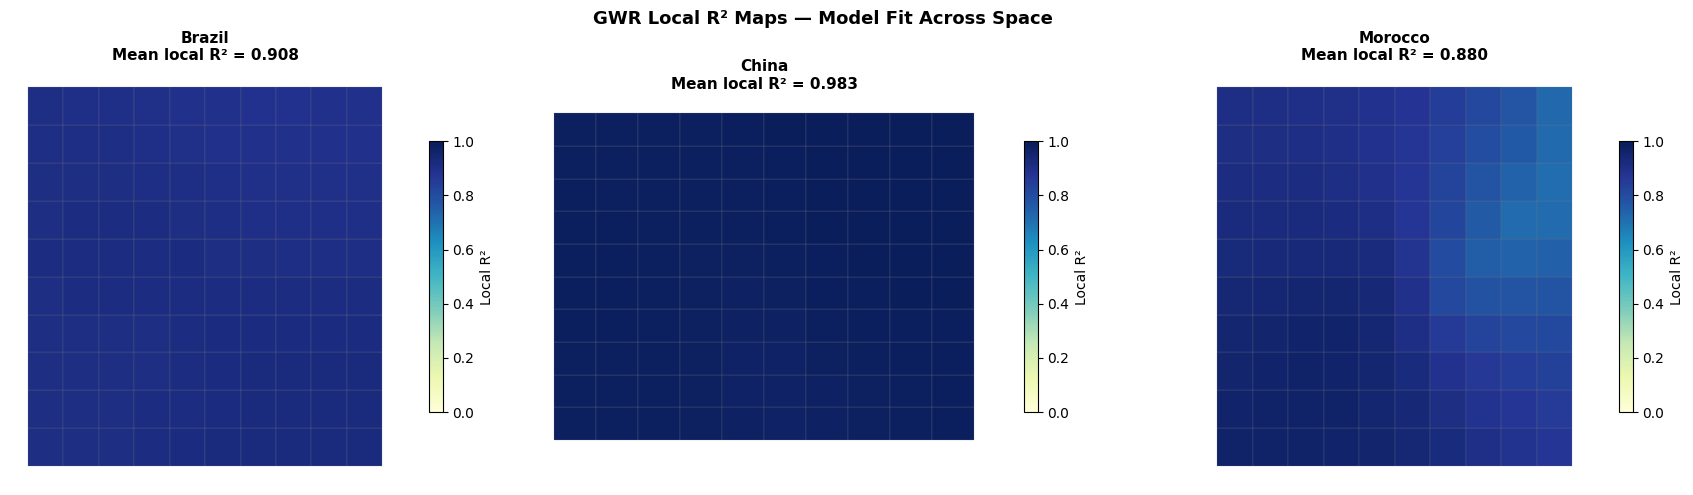

Saved → figures/gwr_local_r2.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (country, gdf) in zip(axes, gdfs.items()):
    results = gwr_results_all[country]
    gdf_plot = gdf.copy()
    gdf_plot['local_r2'] = results.localR2
    gdf_plot.plot(
        column='local_r2', cmap='YlGnBu', vmin=0, vmax=1,
        edgecolor='grey', linewidth=0.15, legend=True,
        legend_kwds={'label': 'Local R²', 'shrink': 0.65}, ax=ax
    )
    mean_r2 = results.localR2.mean()
    ax.set_title(f'{country}\nMean local R² = {mean_r2:.3f}', fontsize=11, fontweight='bold')
    ax.set_axis_off()

fig.suptitle('GWR Local R² Maps — Model Fit Across Space', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / 'gwr_local_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/gwr_local_r2.png')

## 6. Morocco Deep Dive — Western Sahara vs Northern Morocco

The Morocco study area includes Western Sahara (south) and northern Morocco.
We expect different drivers: northern Morocco is urbanised and infrastructure-dense,
while Western Sahara is sparsely populated with very different access dynamics.

Mean GWR coefficients by region:
                  coef_infra  coef_dist  ntl_mean
region                                           
Northern Morocco      0.5359     0.3793    3.7991
Western Sahara        0.4783     0.3475    4.3767


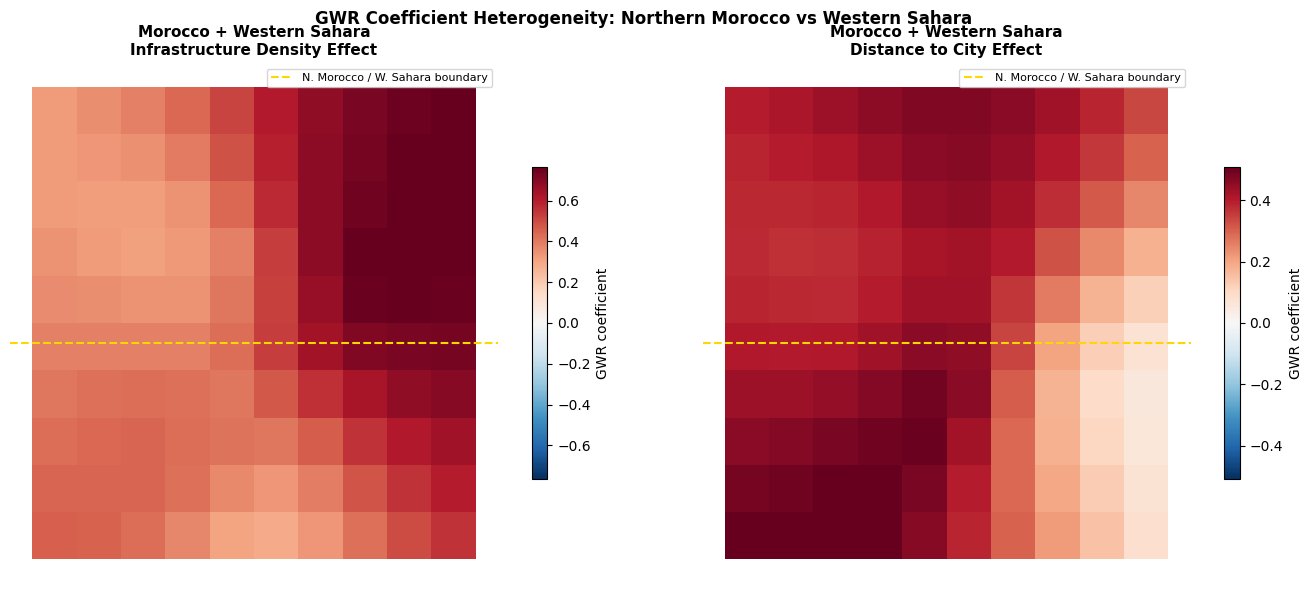

Saved → figures/gwr_morocco_deep_dive.png


In [7]:
gdf_mar = gdfs['Morocco'].copy()
results_mar = gwr_results_all['Morocco']

# Split into Western Sahara (lat < 27.7) and Northern Morocco
gdf_mar['lat'] = gdf_mar.geometry.centroid.y
gdf_mar['region'] = gdf_mar['lat'].apply(
    lambda y: 'Western Sahara' if y < 27.7 else 'Northern Morocco'
)

# Compare local coefficients by region
gdf_mar['coef_infra'] = results_mar.params[:, FEATURES.index('infra_density') + 1]
gdf_mar['coef_dist']  = results_mar.params[:, FEATURES.index('dist_city_km') + 1]

print("Mean GWR coefficients by region:")
print(gdf_mar.groupby('region')[['coef_infra', 'coef_dist', 'ntl_mean']].mean().round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coef_col, title in zip(axes,
    ['coef_infra', 'coef_dist'],
    ['Infrastructure Density Effect', 'Distance to City Effect']):
    vmax = gdf_mar[coef_col].abs().quantile(0.95)
    gdf_mar.plot(column=coef_col, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                 edgecolor='none', legend=True,
                 legend_kwds={'label': 'GWR coefficient', 'shrink': 0.6}, ax=ax)
    # Mark the 27.7°N boundary
    ax.axhline(27.7, color='gold', linewidth=1.5, linestyle='--', label='N. Morocco / W. Sahara boundary')
    ax.legend(fontsize=8)
    ax.set_title(f'Morocco + Western Sahara\n{title}', fontsize=11, fontweight='bold')
    ax.set_axis_off()

fig.suptitle('GWR Coefficient Heterogeneity: Northern Morocco vs Western Sahara',
             fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / 'gwr_morocco_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/gwr_morocco_deep_dive.png')